In [33]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
import pickle

from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [3]:
# -----------------------------------
# 1. 데이터 불러오기
# -----------------------------------
df = pd.read_csv("../datasets/ecommerce_customer_data.csv")

# 데이터 확인
print("데이터 크기:", df.shape)
print(df.head())

데이터 크기: (2000, 9)
   Customer_ID  Age  Gender  Annual_Income  Spending_Score  Membership_Years  \
0            1   56    Male          69812              88               3.2   
1            2   69  Female          70500              26               4.3   
2            3   46  Female          99151              17               8.2   
3            4   32    Male          78643              71               0.6   
4            5   60  Female          64900              13               6.7   

   Online_Purchases  Discount_Usage  Churn  
0                92            0.43      1  
1                30            0.23      1  
2               199            0.52      0  
3               153            0.25      0  
4               127            0.94      0  


Age: 나이
Gender: 성별
Annual_Income: 연소득
Spending_Score: 소비 성향 점수
Membership_Years: 멤버십 유지 기간
Online_Purchases: 온라인 구매 횟수
Discount_Usage: 할인 사용 정도
Churn: 이탈 여부

Customer_ID는 식별자라 제거해야 함
클래스가 약간 불균형
Churn=0: 1379
Churn=1: 621
수치형 변수들 간 단순 선형 상관이 강하지 않음
즉 로지스틱 회귀 하나로는 분리가 잘 안 될 수도 있고, 트리 계열이 더 나을 가능성이 있습니다.

In [4]:
# -----------------------------------
# 2. 입력(X), 타깃(y) 분리
# -----------------------------------
X = df.drop(columns=["Customer_ID", "Churn"])
y = df["Churn"]

# -----------------------------------
# 3. 범주형 변수 인코딩
# Gender를 숫자로 변환
# -----------------------------------
X = pd.get_dummies(X, columns=["Gender"], drop_first=True)

print("\n전처리 후 입력 데이터 컬럼:")
print(X.columns)

# -----------------------------------
# 4. train / val / test 분리
# stratify=y 로 클래스 비율 유지
# -----------------------------------

# 1차 분할: train 70%, temp 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 2차 분할: temp 30%를 val 15%, test 15%로 반반 분할
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

total = len(X)

print("\n" + "="*50)
print("데이터 분할 결과")
print("="*50)
print(f"전체 데이터 수      : {total}")
print(f"훈련 데이터 (train): X={X_train.shape}, y={y_train.shape}, 비율={len(X_train)/total:.1%}")
print(f"검증 데이터 (val)  : X={X_val.shape}, y={y_val.shape}, 비율={len(X_val)/total:.1%}")
print(f"테스트 데이터 (test): X={X_test.shape}, y={y_test.shape}, 비율={len(X_test)/total:.1%}")

# -----------------------------------
# 5. Logistic Regression용 스케일링
# 트리 계열은 스케일링 없이도 됨
# -----------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


전처리 후 입력 데이터 컬럼:
Index(['Age', 'Annual_Income', 'Spending_Score', 'Membership_Years',
       'Online_Purchases', 'Discount_Usage', 'Gender_Male'],
      dtype='str')

데이터 분할 결과
전체 데이터 수      : 2000
훈련 데이터 (train): X=(1400, 7), y=(1400,), 비율=70.0%
검증 데이터 (val)  : X=(300, 7), y=(300,), 비율=15.0%
테스트 데이터 (test): X=(300, 7), y=(300,), 비율=15.0%


In [13]:
# -----------------------------------
# 6. 모델 생성
# -----------------------------------
log_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
)

tree_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion="gini",
    random_state=42,
    class_weight="balanced",
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
    min_samples_split=30,
    min_samples_leaf=15,
    random_state=42,
    class_weight="balanced",
)

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_model(model_name, y_true, y_pred, split_name):
    print("\n" + "="*60)
    print(f"{model_name} | {split_name} 결과")
    print("="*60)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

In [7]:
# -----------------------------------
# 7. Logistic Regression 학습 및 평가
# -----------------------------------
log_model.fit(X_train_scaled, y_train)

# 예측
y_pred_log_train = log_model.predict(X_train_scaled)
y_pred_log_val = log_model.predict(X_val_scaled)
y_pred_log_test = log_model.predict(X_test_scaled)

# 평가
evaluate_model("Logistic Regression", y_train, y_pred_log_train, "Train")
evaluate_model("Logistic Regression", y_val, y_pred_log_val, "Validation")
evaluate_model("Logistic Regression", y_test, y_pred_log_test, "Test")


Logistic Regression | Train 결과
Accuracy: 0.5214285714285715
Confusion Matrix:
 [[503 462]
 [208 227]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.52      0.60       965
           1       0.33      0.52      0.40       435

    accuracy                           0.52      1400
   macro avg       0.52      0.52      0.50      1400
weighted avg       0.59      0.52      0.54      1400


Logistic Regression | Validation 결과
Accuracy: 0.49333333333333335
Confusion Matrix:
 [[106 101]
 [ 51  42]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.51      0.58       207
           1       0.29      0.45      0.36        93

    accuracy                           0.49       300
   macro avg       0.48      0.48      0.47       300
weighted avg       0.56      0.49      0.51       300


Logistic Regression | Test 결과
Accuracy: 0.5233333333333333
Confusion Matrix:
 [[107 1

In [8]:
# -----------------------------------
# 8. Decision Tree 학습 및 평가
# -----------------------------------
tree_model.fit(X_train, y_train)

# 예측
y_pred_tree_train = tree_model.predict(X_train)
y_pred_tree_val = tree_model.predict(X_val)
y_pred_tree_test = tree_model.predict(X_test)

# 평가
evaluate_model("Decision Tree", y_train, y_pred_tree_train, "Train")
evaluate_model("Decision Tree", y_val, y_pred_tree_val, "Validation")
evaluate_model("Decision Tree", y_test, y_pred_tree_test, "Test")


Decision Tree | Train 결과
Accuracy: 0.6014285714285714
Confusion Matrix:
 [[617 348]
 [210 225]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.64      0.69       965
           1       0.39      0.52      0.45       435

    accuracy                           0.60      1400
   macro avg       0.57      0.58      0.57      1400
weighted avg       0.64      0.60      0.61      1400


Decision Tree | Validation 결과
Accuracy: 0.4766666666666667
Confusion Matrix:
 [[112  95]
 [ 62  31]]
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.54      0.59       207
           1       0.25      0.33      0.28        93

    accuracy                           0.48       300
   macro avg       0.44      0.44      0.44       300
weighted avg       0.52      0.48      0.49       300


Decision Tree | Test 결과
Accuracy: 0.5
Confusion Matrix:
 [[113  94]
 [ 56  37]]
Classification Rep

In [14]:
# -----------------------------------
# 9. Random Forest 학습 및 평가
# -----------------------------------
rf_model.fit(X_train, y_train)

# 예측
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_val = rf_model.predict(X_val)
y_pred_rf_test = rf_model.predict(X_test)

# 평가
evaluate_model("Random Forest", y_train, y_pred_rf_train, "Train")
evaluate_model("Random Forest", y_val, y_pred_rf_val, "Validation")
evaluate_model("Random Forest", y_test, y_pred_rf_test, "Test")


Random Forest | Train 결과
Accuracy: 0.6771428571428572
Confusion Matrix:
 [[712 253]
 [199 236]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.74      0.76       965
           1       0.48      0.54      0.51       435

    accuracy                           0.68      1400
   macro avg       0.63      0.64      0.63      1400
weighted avg       0.69      0.68      0.68      1400


Random Forest | Validation 결과
Accuracy: 0.5466666666666666
Confusion Matrix:
 [[135  72]
 [ 64  29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.65      0.67       207
           1       0.29      0.31      0.30        93

    accuracy                           0.55       300
   macro avg       0.48      0.48      0.48       300
weighted avg       0.56      0.55      0.55       300


Random Forest | Test 결과
Accuracy: 0.5266666666666666
Confusion Matrix:
 [[127  80]
 [ 62  31]]
Cla

In [10]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Logistic Regression", "Logistic Regression",
              "Decision Tree", "Decision Tree", "Decision Tree",
              "Random Forest", "Random Forest", "Random Forest"],
    "Split": ["Train", "Validation", "Test",
              "Train", "Validation", "Test",
              "Train", "Validation", "Test"],
    "Accuracy": [
        accuracy_score(y_train, y_pred_log_train),
        accuracy_score(y_val, y_pred_log_val),
        accuracy_score(y_test, y_pred_log_test),

        accuracy_score(y_train, y_pred_tree_train),
        accuracy_score(y_val, y_pred_tree_val),
        accuracy_score(y_test, y_pred_tree_test),

        accuracy_score(y_train, y_pred_rf_train),
        accuracy_score(y_val, y_pred_rf_val),
        accuracy_score(y_test, y_pred_rf_test),
    ]
})

print(results)

                 Model       Split  Accuracy
0  Logistic Regression       Train  0.521429
1  Logistic Regression  Validation  0.493333
2  Logistic Regression        Test  0.523333
3        Decision Tree       Train  0.601429
4        Decision Tree  Validation  0.476667
5        Decision Tree        Test  0.500000
6        Random Forest       Train  0.869286
7        Random Forest  Validation  0.563333
8        Random Forest        Test  0.553333


In [65]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", log_model),
        ("dt", tree_model),
        ("rf", rf_model)
    ],
    voting="soft"
)

voting_model.fit(X_train, y_train)
y_prob_vote = voting_model.predict_proba(X_test)[:, 1]
y_pred_vote = (y_prob_vote >= 0.7).astype(int)

In [66]:
print("\n" + "="*50)
print("Voting model 결과")
print("="*50)
print("Accuracy:", accuracy_score(y_test, y_pred_vote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_vote))
print("Classification Report:\n", classification_report(y_test, y_pred_vote))


Voting model 결과
Accuracy: 0.69
Confusion Matrix:
 [[276   0]
 [124   0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      1.00      0.82       276
           1       0.00      0.00      0.00       124

    accuracy                           0.69       400
   macro avg       0.34      0.50      0.41       400
weighted avg       0.48      0.69      0.56       400



c:\Users\Playdata\miniforge3\envs\ai_basic_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Playdata\miniforge3\envs\ai_basic_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Playdata\miniforge3\envs\ai_basic_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

현재 답에서 1을 못 잡고 다 0으로만 찍는 상태  

“1을 더 많이 잡으려면 무엇을 바꿔야 하나?”  

핵심은 5가지입니다.  

1. 평가 기준부터 바꾸기  

이제 accuracy는 주지표로 두면 안 됩니다.  

대신 이런 걸 봐야 합니다.  

Recall(1 클래스 기준)  
Precision(1 클래스 기준)  
F1-score  
가능하면 PR-AUC  

왜냐하면 지금은 “1을 놓치지 않는 것”이 중요하기 때문입니다.  

예를 들어 모델 비교도 이렇게 해야 합니다.  

accuracy가 조금 떨어져도  
1 recall이 크게 오르면  
더 좋은 모델일 수 있음  

In [50]:
# -----------------------------------
# 1. XGBoost 모델 생성
# -----------------------------------
xgb_model = XGBClassifier(
    n_estimators=250,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2,
    random_state=42,
    eval_metric="logloss"
)


In [51]:
# -----------------------------------
# 2. XGBoost 학습
# -----------------------------------
xgb_model.fit(X_train, y_train)

# -----------------------------------
# 3. XGBoost 기본 예측 (기본 threshold=0.5 느낌)
# -----------------------------------
y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_val = xgb_model.predict(X_val)

# -----------------------------------
# 4. XGBoost 기본 평가
# -----------------------------------
evaluate_model("XGBoost", y_train, y_pred_xgb_train, "Train")
evaluate_model("XGBoost", y_val, y_pred_xgb_val, "Validation (default threshold)")

# -----------------------------------
# 5. Validation에서 threshold 탐색
# -----------------------------------
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

for th in [0.3, 0.4, 0.5, 0.6]:
    y_val_pred_xgb = (y_val_prob_xgb >= th).astype(int)
    print(f"\nthreshold={th}")
    print(classification_report(y_val, y_val_pred_xgb, zero_division=0))

# -----------------------------------
# 6. 원하는 threshold를 직접 선택
# -----------------------------------
best_threshold = 0.285

# validation에서 선택한 threshold 적용
y_val_pred_xgb_best = (y_val_prob_xgb >= best_threshold).astype(int)

print("\n" + "="*60)
print(f"XGBoost | Validation 결과 (threshold={best_threshold})")
print("="*60)
print("Accuracy:", accuracy_score(y_val, y_val_pred_xgb_best))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred_xgb_best))
print("Classification Report:\n", classification_report(y_val, y_val_pred_xgb_best, zero_division=0))

# -----------------------------------
# 7. 이제 test에 최종 적용
# -----------------------------------
y_test_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb_test = (y_test_prob_xgb >= best_threshold).astype(int)

print("\n" + "="*60)
print(f"XGBoost | Test 결과 (threshold={best_threshold})")
print("="*60)
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_test))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_test, zero_division=0))


XGBoost | Train 결과
Accuracy: 0.7621428571428571
Confusion Matrix:
 [[959   6]
 [327 108]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.99      0.85       965
           1       0.95      0.25      0.39       435

    accuracy                           0.76      1400
   macro avg       0.85      0.62      0.62      1400
weighted avg       0.81      0.76      0.71      1400


XGBoost | Validation (default threshold) 결과
Accuracy: 0.66
Confusion Matrix:
 [[193  14]
 [ 88   5]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.93      0.79       207
           1       0.26      0.05      0.09        93

    accuracy                           0.66       300
   macro avg       0.47      0.49      0.44       300
weighted avg       0.56      0.66      0.57       300


threshold=0.3
              precision    recall  f1-score   support

           0       0.68      0.54  

In [ ]:
# -----------------------------------
# 5. CatBoost 모델 생성
# verbose=0 으로 학습 로그 출력 억제
# -----------------------------------
cat_model = CatBoostClassifier(
    iterations=250,
    depth=4,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=0
)

In [19]:
# -----------------------------------
# 6. CatBoost 학습
# -----------------------------------
cat_model.fit(X_train, y_train)

# -----------------------------------
# 7. CatBoost 예측
# -----------------------------------
y_pred_cat_train = cat_model.predict(X_train)
y_pred_cat_val = cat_model.predict(X_val)
y_pred_cat_test = cat_model.predict(X_test)

# predict 결과를 shape 맞게 1차원으로 정리
y_pred_cat_train = pd.Series(y_pred_cat_train.ravel())
y_pred_cat_val = pd.Series(y_pred_cat_val.ravel())
y_pred_cat_test = pd.Series(y_pred_cat_test.ravel())

# -----------------------------------
# 8. CatBoost 평가
# -----------------------------------
evaluate_model("CatBoost", y_train, y_pred_cat_train, "Train")
evaluate_model("CatBoost", y_val, y_pred_cat_val, "Validation")
evaluate_model("CatBoost", y_test, y_pred_cat_test, "Test")


CatBoost | Train 결과
Accuracy: 0.7764285714285715
Confusion Matrix:
 [[963   2]
 [311 124]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      1.00      0.86       965
           1       0.98      0.29      0.44       435

    accuracy                           0.78      1400
   macro avg       0.87      0.64      0.65      1400
weighted avg       0.83      0.78      0.73      1400


CatBoost | Validation 결과
Accuracy: 0.68
Confusion Matrix:
 [[196  11]
 [ 85   8]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.95      0.80       207
           1       0.42      0.09      0.14        93

    accuracy                           0.68       300
   macro avg       0.56      0.52      0.47       300
weighted avg       0.61      0.68      0.60       300


CatBoost | Test 결과
Accuracy: 0.6533333333333333
Confusion Matrix:
 [[193  14]
 [ 90   3]]
Classification Report:
         

현재까지 돌려본 결과 XGboost가 제일 상태가 좋은 것을 알 수 있다.  
XGBoost는 결정트리를 여러 개 이어서 점점 정답에 가깝게 만드는 머신러닝 모델이고, 비선형 방식을 잘 잡는다.

In [52]:
# 저장
with open("../artifacts/xg_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

In [69]:
# 불러오기
with open("../artifacts/voting_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [ ]:
# 불러오기
with open("../artifacts/xg_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 한글 깨짐 방지 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

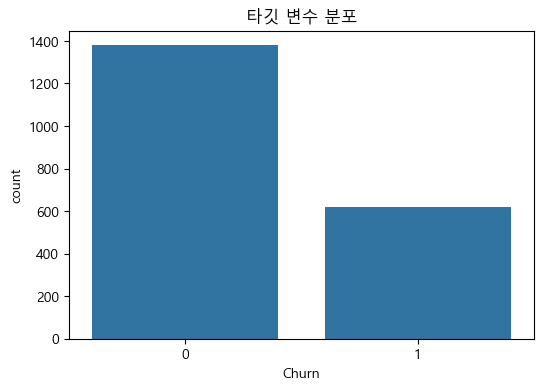

In [48]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)
plt.title("타깃 변수 분포")
plt.show()